# Cells for running the package simulations in order to check its results

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import casadi as ca
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src")) # Source code
from benchmark_systems.symbolic import (
    dc_motor,
    pendulum,
    cart_pendulum,
    multimass_spring,
    double_cart_pendulum,
    multilevel_cart_pendulum,
    quadrotor_dae,
    quadrotor_ode,
    cstr,
    batch_bioreactor,
    johansson,
    oil_well,
    neutralization,
    solve_ivp_casadi,
    solve_dae_casadi,
)

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (12, 6)})

### DC-Motor

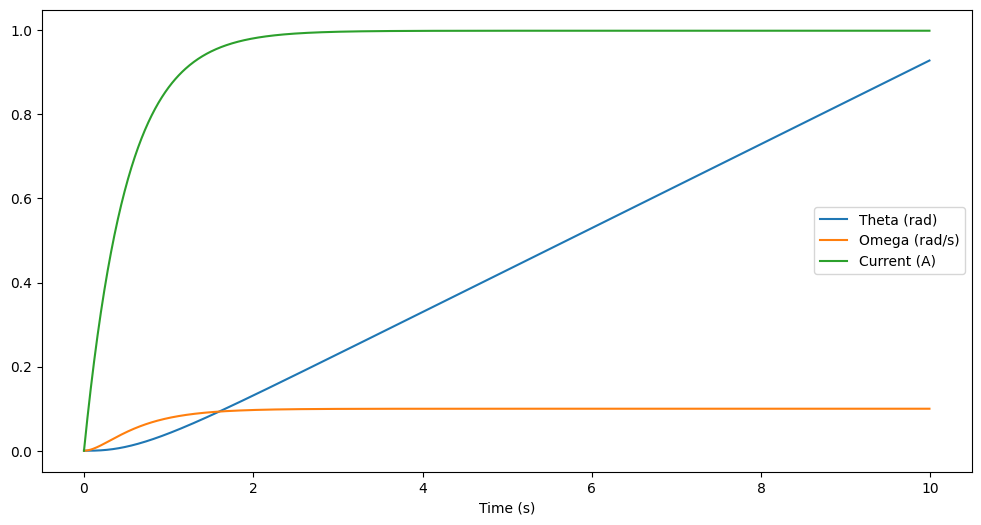

In [3]:
dcmotor_states = solve_ivp_casadi(dc_motor(R=1, L=0.5, Kt=0.01, Ke=0.01, J=0.02, b=0.1),
                            t_span=(0, 10), y0=[0, 0, 0], u=1)

for i, label in enumerate(['Theta (rad)', 'Omega (rad/s)', 'Current (A)']):
    plt.plot(dcmotor_states.t, dcmotor_states.y[i], label=label)
plt.xlabel('Time (s)')
plt.legend()

### Simple pendulum

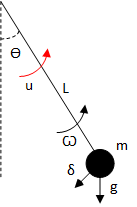

States: $x = \begin{bmatrix} \theta \\ \omega \end{bmatrix}$; Control actions: $u$

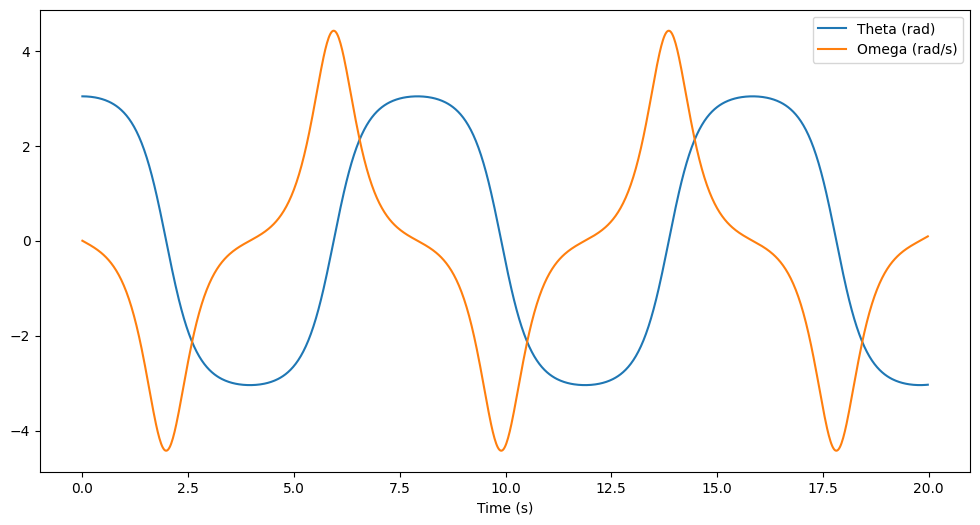

In [4]:
pendulum_states = solve_ivp_casadi(pendulum(m=1, L=2, drag=0),
                            t_span=(0, 20), y0=[np.pi-0.1, 0], u=0)

for i, label, in enumerate(['Theta (rad)', 'Omega (rad/s)']):
    plt.plot(pendulum_states.t, pendulum_states.y[i], label=label)
plt.xlabel('Time (s)')
plt.legend()

### Cart-Pendulum

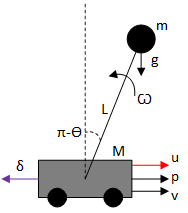

States: $x = \begin{bmatrix} p \\ v \\ \theta \\ \omega \end{bmatrix}$; Control actions: $u$

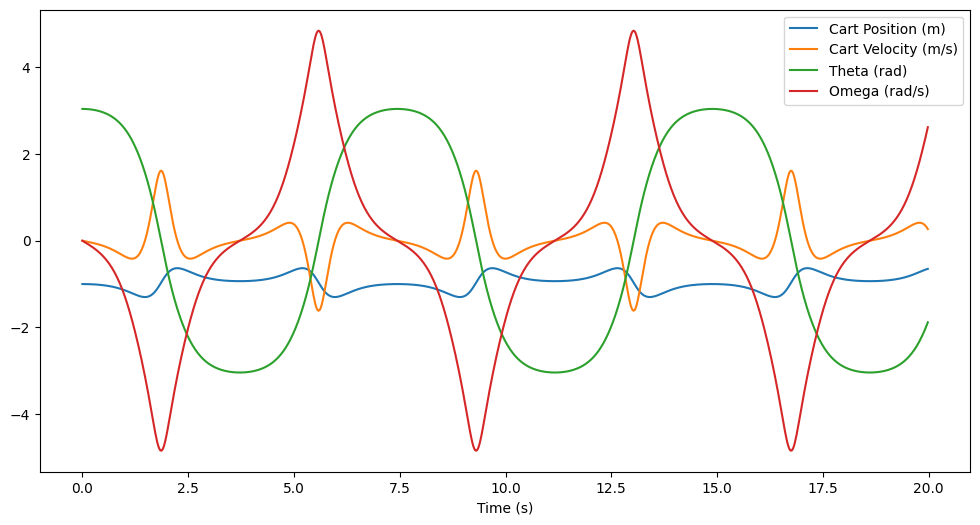

In [5]:
cp_states = solve_ivp_casadi(cart_pendulum(m=1, M=5, L=2, drag=0),
                            t_span=(0, 20), y0=[-1, 0, np.pi-0.1, 0])

for i, label in enumerate(['Cart Position (m)', 'Cart Velocity (m/s)', 'Theta (rad)', 'Omega (rad/s)']):
    plt.plot(cp_states.t, cp_states.y[i], label=label)
plt.xlabel('Time (s)')
plt.legend()

### Double Inverted Pendulum

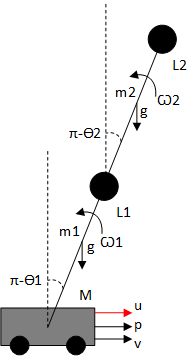

States: $x = \begin{bmatrix} p \\ \theta_1 \\ \theta_2 \\ v \\ \omega_1 \\ \omega_2 \end{bmatrix}$; Control actions: $u$

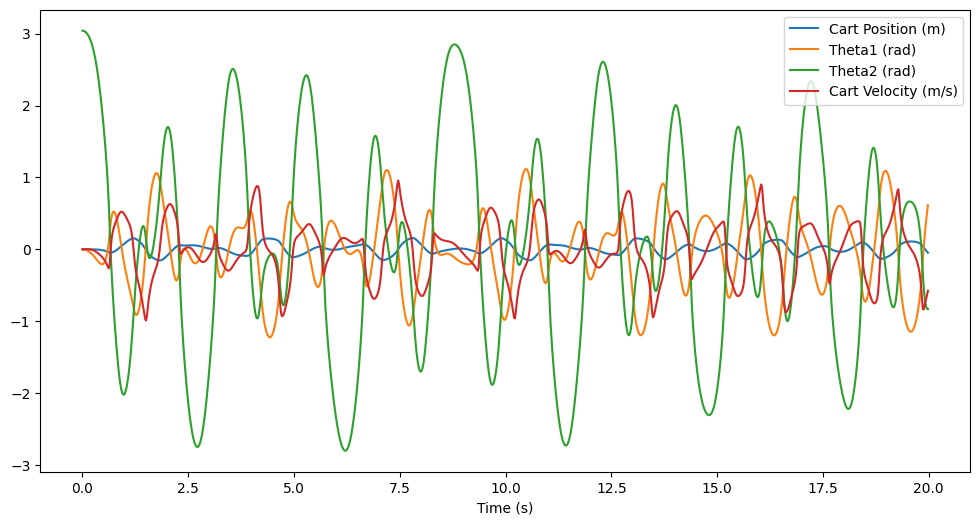

In [3]:
dip_states = solve_dae_casadi(double_cart_pendulum(M=0.6, m1=0.2, m2=0.2, L1=0.5, L2=0.5),
                       t_span=(0, 20), y0=[0, 0, np.pi-0.1, 0, 0, 0], yp0=np.zeros(6), opts={'reltol': 5e-5})

for i, label in enumerate(['Cart Position (m)', 'Theta1 (rad)', 'Theta2 (rad)', 'Cart Velocity (m/s)']):
    plt.plot(dip_states.t, dip_states.y[i], label=label)
plt.xlabel('Time (s)')
plt.legend()

### Triple Inverted Pendulum

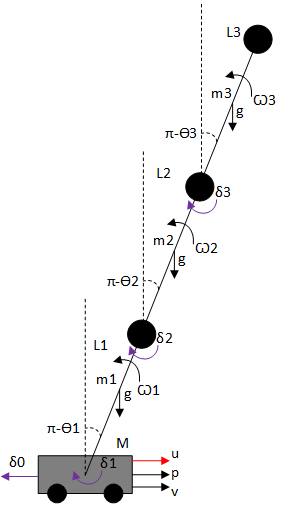

States: $x = \begin{bmatrix} p \\ \theta_1 \\ \theta_2 \\ \theta_3 \\ v \\ \omega_1 \\ \omega_2 \\ \omega_3 \end{bmatrix}$; Control actions: $u$

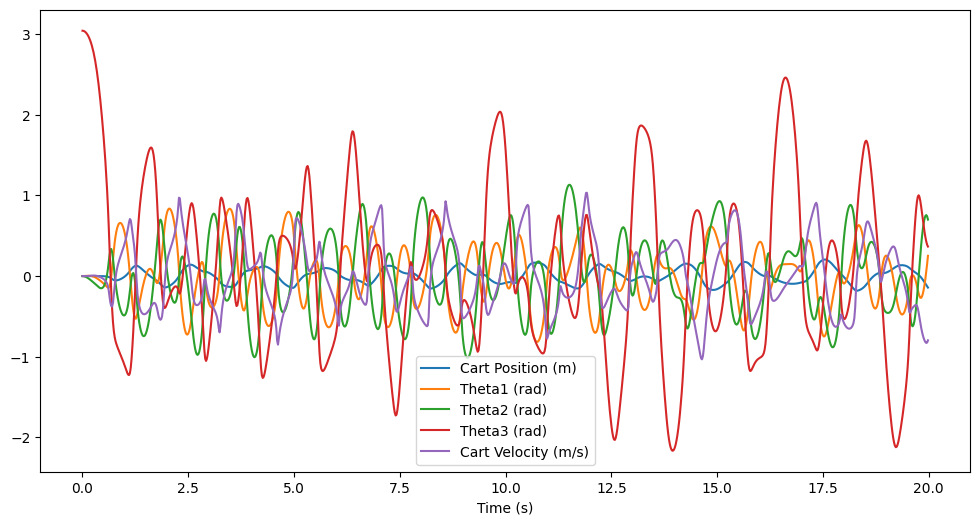

In [ ]:
tip_states = solve_dae_casadi(multilevel_cart_pendulum(M=0.6, m=[0.2]*3, L=[0.5]*3),
                       t_span=(0, 20), y0=[0, 0, 0, np.pi-0.1, 0, 0, 0, 0], yp0=np.zeros(8), opts={'reltol': 1e-5})

for i, label in enumerate(['Cart Position (m)', 'Theta1 (rad)', 'Theta2 (rad)', 'Theta3 (rad)', 'Cart Velocity (m/s)']):
    plt.plot(tip_states.t, tip_states.y[i], label=label)
plt.xlabel('Time (s)')
plt.legend()

### Multimass Spring System

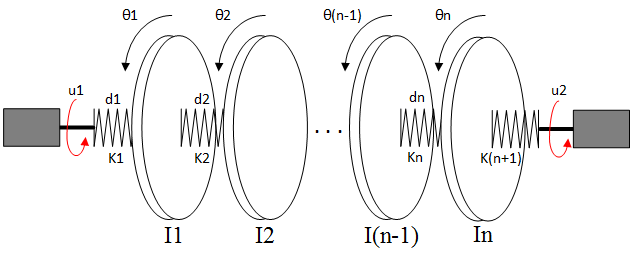

States: $x = \begin{bmatrix} u^{true}_1 \\ u^{true}_2 \\ \theta_1 \\ \theta_2 \\ \dots \\ \theta_n \\
\dot{\theta}_1 \\ \dot{\theta}_2 \\ \dots \\ \dot{\theta}_n \end{bmatrix}$; Control actions: $u = \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$

In [8]:
multimass_params = {
    'tau': [1e-2]*2, # Time constants of the stepper motors
    'I': [2.25*1e-4]*3, # Inertia of each mass
    'K': np.array([2.697,  2.66,  3.05, 2.86])*1e-3, # Spring constants
    'd': np.array([6.78,  8.01,  8.82])*1e-5, # Damping constants
}

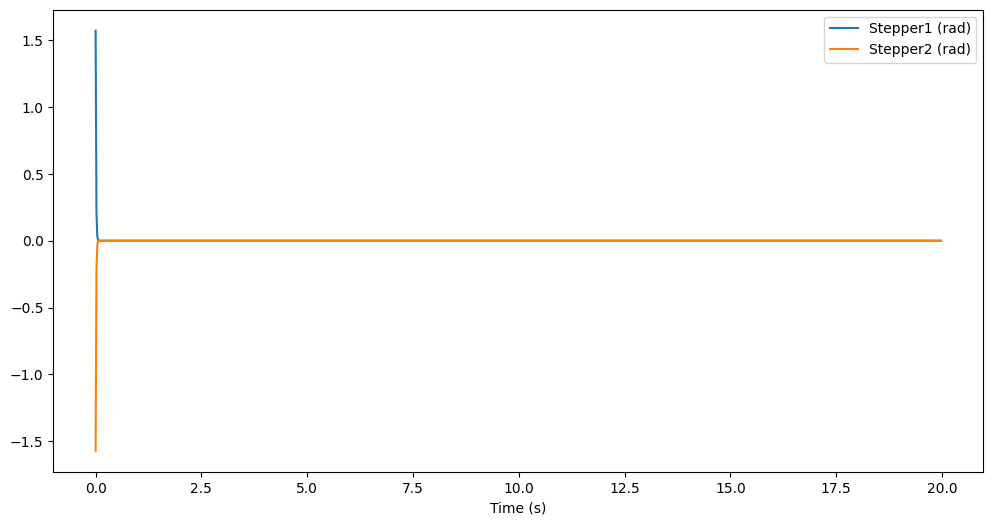

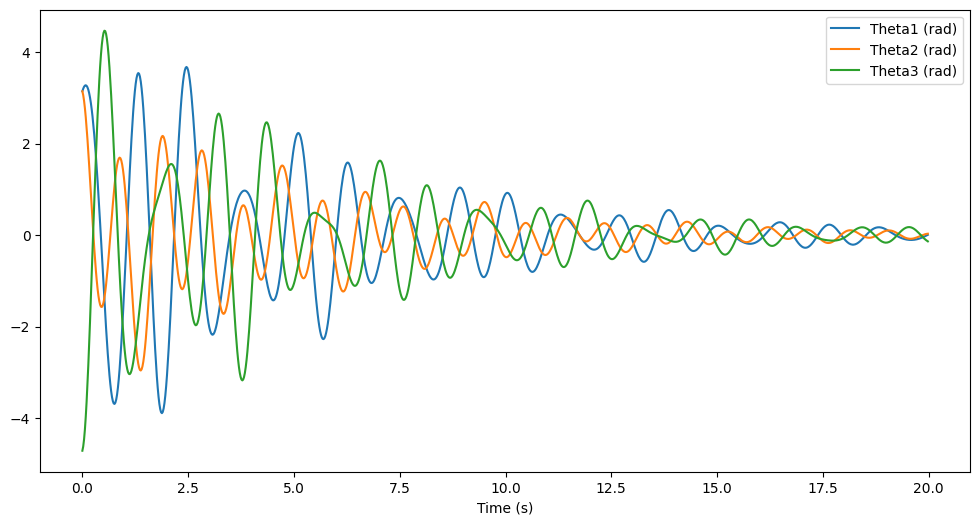

In [9]:
damper_states = solve_ivp_casadi(multimass_spring(**multimass_params),
                            t_span=(0, 20), y0=np.pi*np.array([0.5, -0.5, 1, 1, -1.5, 1, -1, 1]), u=[0, 0])

for i, label in enumerate(['Stepper1 (rad)', 'Stepper2 (rad)']):
    plt.plot(damper_states.t, damper_states.y[i], label=label)
plt.xlabel('Time (s)')
plt.legend()

plt.figure()
for i, label in enumerate(['Theta1 (rad)', 'Theta2 (rad)', 'Theta3 (rad)'], start=2):
    plt.plot(damper_states.t, damper_states.y[i], label=label)
plt.xlabel('Time (s)')
plt.legend()

### Johansson's 4 tank system

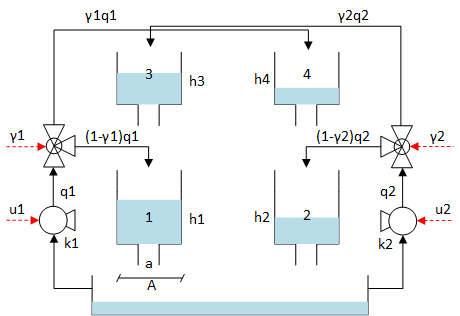

States: $x = \begin{bmatrix} h_1 \\ h_2 \\ h_3 \\ h_4 \end{bmatrix}$; Control actions: $u = \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$

In [10]:
johansson_params = {
    'h_max': [25, 25, 20, 20], # cm
    'A' : [389.16] * 4, #cm^2
    'a': [((1.4/2) ** 2) * np.pi] * 4, # cm^2
    'K' : [6.74, 7.94],
    'gamma': [0.7, 0.6] # Non-minimum phase configuration
}

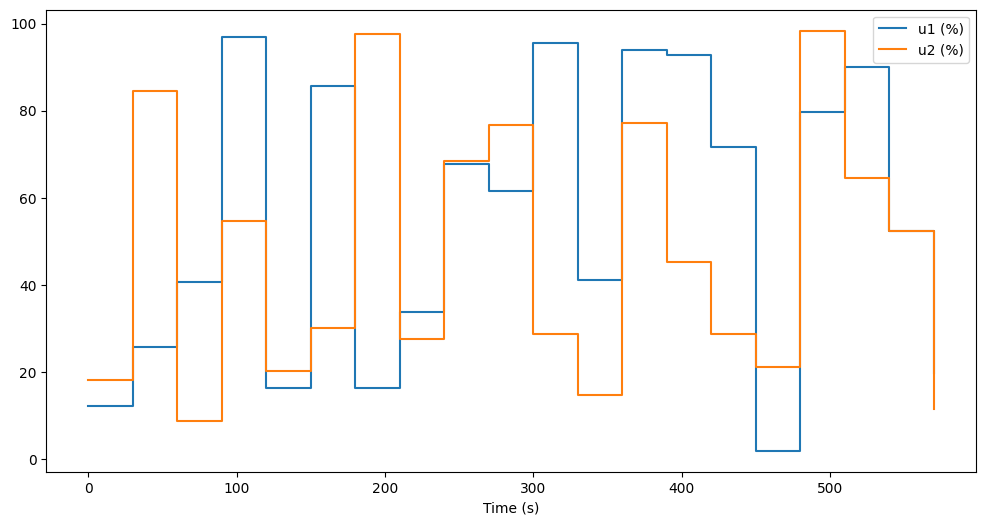

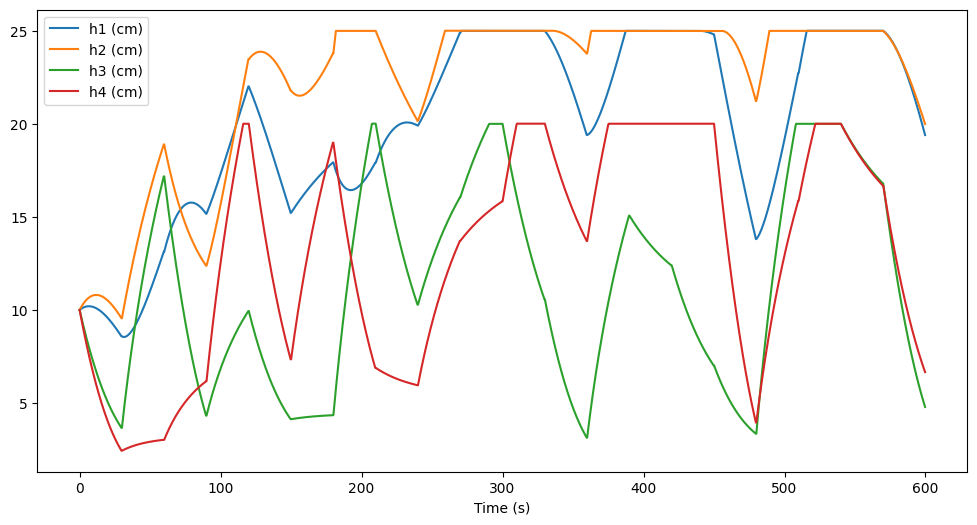

In [11]:
duration = 30 # seconds
Ts = 0.3 # seconds

# 20 random setpoints (0-100) for pump 1 and 2.
rangen = np.random.default_rng(seed=44)
u1, u2 = [rangen.random(20)*100 for _ in range(2)]
gamma1, gamma2 = johansson_params.pop('gamma')

# Simulation of the system ... Every setpoint is held for 30 seconds
johansson_states = np.array([[] for _ in range(4)])
for u1_k, u2_k in zip(u1, u2):
    # Solve the system for 30 seconds, taking 100 samples in that interval
    heights = solve_ivp_casadi(johansson(**johansson_params), t_span=(0, duration),
                               y0 = [10, 10, 10, 10] if johansson_states.size == 0 else johansson_states[:, -1], u=[u1_k, u2_k, gamma1, gamma2], N=int(duration/Ts))
    # Append the states
    johansson_states = np.hstack([johansson_states, heights.y])

# Plot the setpoints
plt.figure()
plt.step(np.arange(0, 600, 30), u1, label='u1 (%)', where='post')
plt.step(np.arange(0, 600, 30), u2, label='u2 (%)', where='post')
plt.xlabel('Time (s)')
plt.legend()

# Plot heights
plt.figure()
for i, label in enumerate(['h1 (cm)', 'h2 (cm)', 'h3 (cm)', 'h4 (cm)']):
    plt.plot(np.arange(0, 600, 0.3), johansson_states[i], label=label)
plt.xlabel('Time (s)')
plt.legend()

### Batch Bioreactor

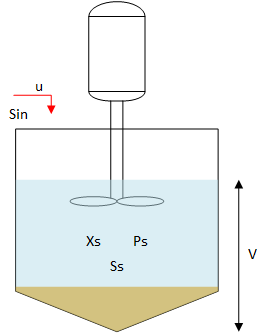

States: $x = \begin{bmatrix} X_s \\ S_s \\ P_s \\ V \end{bmatrix}$; Control actions: $u$

Text(0.5, 0, 'Time (min)')

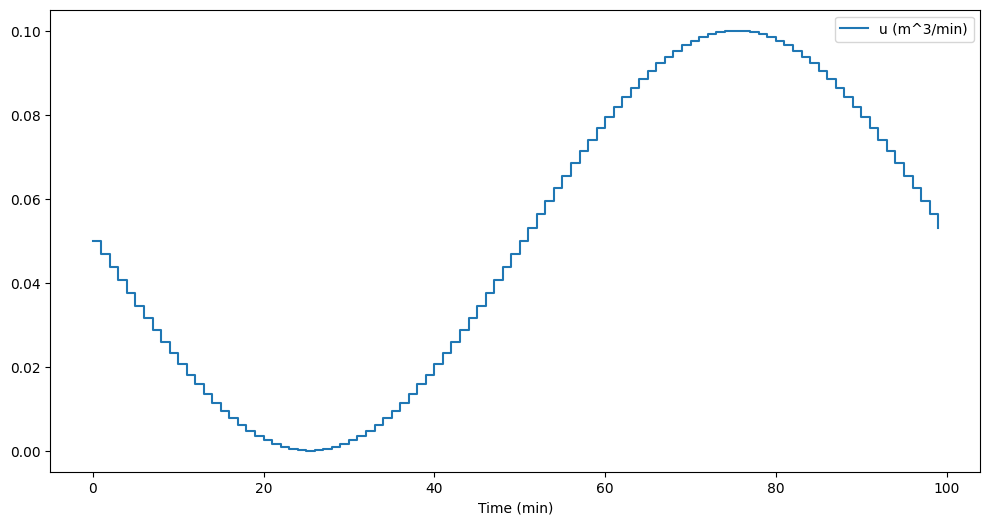

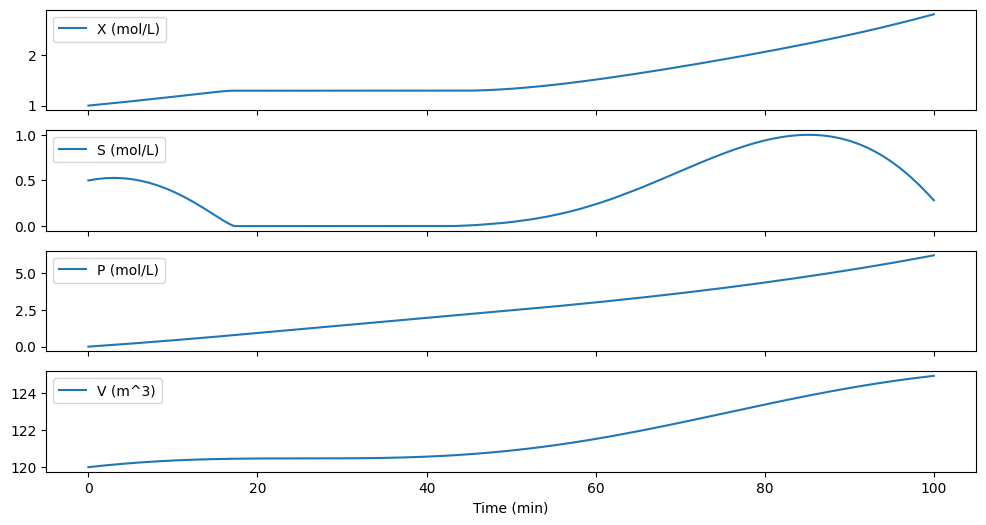

In [12]:
duration = 1 # minutes
Ts = 0.01 # minutes

# Feed flow rate between 0 and 0.1.
k = np.arange(0, duration, Ts)
u = 0.05*(1 + np.sin(2*np.pi*k - np.pi))

# Simulation of the batch reactor ... Every setpoint is held for 1 minute
batch_states = np.array([[] for _ in range(4)])
for u_k in u:
    # Solve the system for 1 minute, taking 100 samples in that interval
    states = solve_ivp_casadi(batch_bioreactor(S_in=200, mu_max=0.02, K_m=0.05, K_i=5, v=0.04, Y_x=0.5, Y_p=1.2), t_span=(0, duration),
                              y0 = [1, 0.5, 0, 120] if batch_states.size == 0 else batch_states[:, -1], u=u_k, N=int(duration/Ts))
    # Append the states
    batch_states = np.hstack([batch_states, states.y])

# Plot feed flow rate
plt.figure()
plt.step(np.arange(100), u, label='u (m^3/min)', where='post')
plt.xlabel('Time (min)')
plt.legend()

# Plot states
fig, axs = plt.subplots(4, 1, sharex=True)
for i, label in enumerate(['X (mol/L)', 'S (mol/L)', 'P (mol/L)', 'V (m^3)']):
    axs[i].plot(np.arange(0, 100, 0.01), batch_states[i], label=label)
    axs[i].legend()
axs[-1].set_xlabel('Time (min)')

### Continuous Stirred Tank Reactor (CSTR)

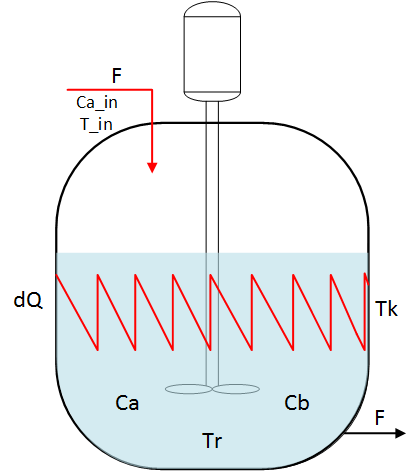

States: $x = \begin{bmatrix} C_a \\ C_b \\ T_r \\ T_k \end{bmatrix}$; Control actions: $u = \begin{bmatrix} F \\ \dot{Q} \end{bmatrix}$

In [13]:
arrhenius_eqs = {
    'K0_ab': 1.287e12, 'Ea_ab': 81.135, 'Hr_ab': 4.2, 
    'K0_bc': 1.287e12, 'Ea_bc': 81.135, 'Hr_bc': -11,
    'K0_ad': 9.043e9, 'Ea_ad': 71.172, 'Hr_ad': -41.85
}
reactor = {
    'rho': 0.9342, 'Cp': 3.01,
    'A': 0.215, 'V': 10, 'K_w': 4032
}
in_flow = {
    'Ca_in': 5.1, 'T_in': 130
}
coolant = {
    'Cp_k': 2, 'm_k': 5
}

Text(0.5, 0, 'Time (h)')

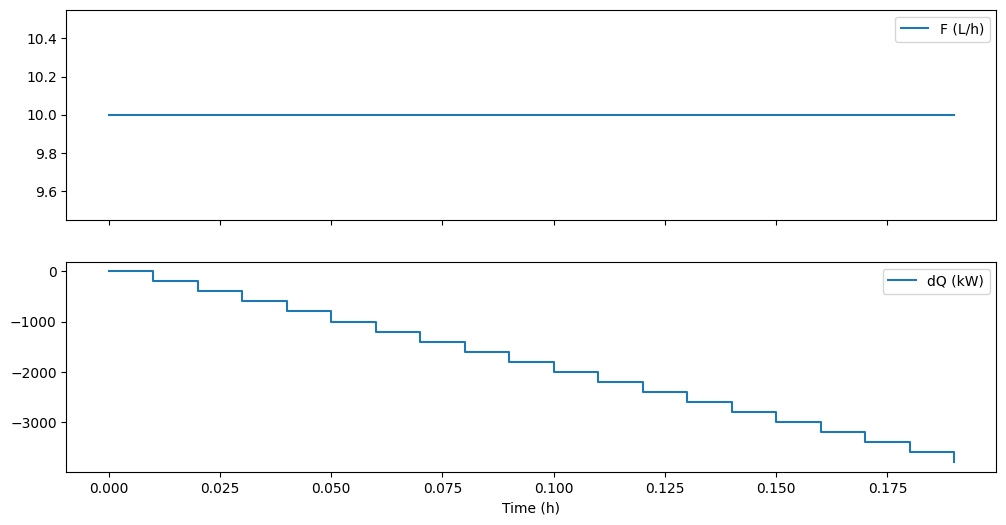

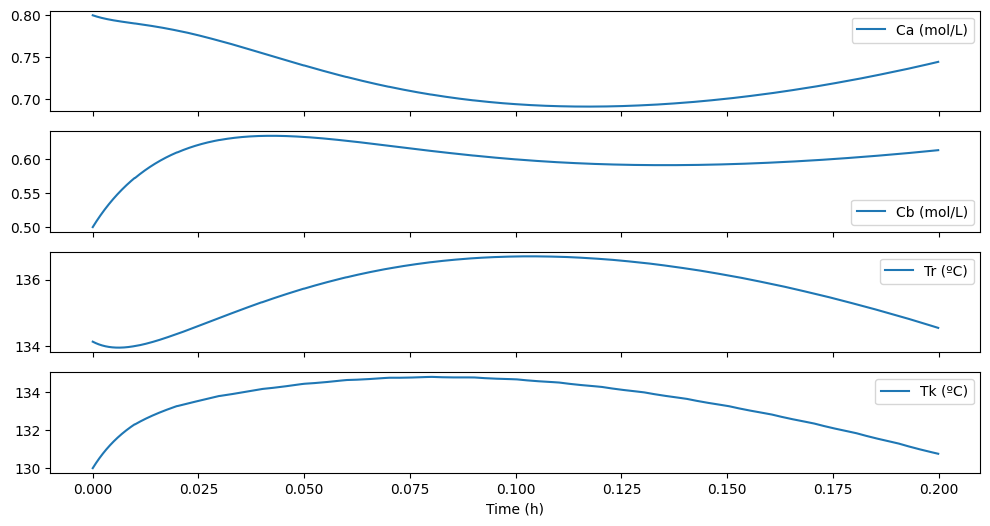

In [14]:
duration = 0.2 # hours
step_duration = 0.01 # hours
Ts = 0.0001 # hours

# Feed flow and heat flow
k = np.arange(0, duration, step_duration)
F = np.ones_like(k) * 10
dQ = -20000 * k
u = np.array([F, dQ]).T

# Simulation of the CSTR ... Every setpoint is held for 0.01 hours
cstr_states = np.array([[] for _ in range(4)])
for F_k, dQ_k in u:
    # Solve the system for 0.01 hours, taking 100 samples in that interval
    states = solve_ivp_casadi(cstr(**arrhenius_eqs, **reactor, **in_flow, **coolant), t_span=(0, step_duration),
                                y0 = [0.8, 0.5, 134.14, 130] if cstr_states.size == 0 else cstr_states[:, -1], u=[F_k, dQ_k], N=int(step_duration/Ts))
    # Append the states
    cstr_states = np.hstack([cstr_states, states.y])

# Plot feed flow rate and heat flow
fig, axs = plt.subplots(2, 1, sharex=True)
for i, label in enumerate(['F (L/h)', 'dQ (kW)']):
    axs[i].step(k, u[:, i], label=label, where='post')
    axs[i].legend()
axs[-1].set_xlabel('Time (h)')

# Plot states
fig, axs = plt.subplots(4, 1, sharex=True)
for i, label in enumerate(['Ca (mol/L)', 'Cb (mol/L)', 'Tr (ºC)', 'Tk (ºC)']): 
    axs[i].plot(np.arange(0, duration,Ts), cstr_states[i], label=label)
    axs[i].legend()
axs[-1].set_xlabel('Time (h)')

### Quadrotor

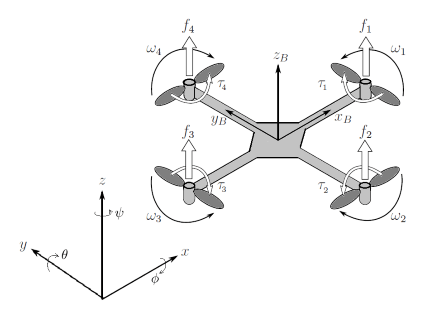

###### Image source: https://es.mathworks.com/help/symbolic/derive-quadrotor-dynamics-for-nonlinearMPC.html

* Newton-Euler model (ODE)
    States: $x = \begin{bmatrix} x \ y \ z \ \phi \ \theta \ \psi \ s \ v \ w \ p \ q \ r \end{bmatrix}^T$; 

* Euler-Lagrange model (DAE)
    States: $x = \begin{bmatrix} x \ y \ z \ \phi \ \theta \ \psi \ \dot{x} \ \dot{y} \ \dot{z} \ \dot{\phi} \ \dot{\theta} \ \dot{\psi} \end{bmatrix}^T$;

Control actions: $u = \begin{bmatrix} \omega_1^2 \ \omega_2^2 \ \omega_3^2 \ \omega_4^2 \end{bmatrix}^T$

In [9]:
quadrotor_params = {
    'Ixx': 1.2, 'Iyy': 1.2, 'Izz': 2.3, 'k': 1, 'L': 0.25, 'm': 2, 'drag': 0.2
}
quadrotor_params = {
    'Ixx': 1.2, 'Iyy': 1.2, 'Izz': 2.3, 'k': 1, 'L': 0.25, 'm': 2, 'drag': 0.2
}
w2 = quadrotor_params['m']*9.81/(quadrotor_params['k']*4) # Squared speed of the propellers in order to hover ... 4*k*w^2 = m*g
u = 4*[w2] # Hover

Get the nonlinear dynamics as a CasADi function:

In [10]:
quadrotor_fn = quadrotor_ode(**quadrotor_params)
quadrotor_fn

Function(quadrotor:(t,x[12],u[4])->(dx[12]) SXFunction)

Linearize the dynamics around the hover equilibrium point:

In [11]:
jac_quadrotor = quadrotor_fn.jacobian()(t=0.0, x=[0, 0, 5] + 9*[0], u=u)
A = jac_quadrotor['jac_dx_x']
B = jac_quadrotor['jac_dx_u']

Compute the LQR controller for the linearized system, using only the first 6 states (position and angles) in the cost function:

In [12]:
from control import lqr
C = np.zeros((6, 12)) # Output matrix
C[:6, :6] = np.eye(6) # Position and angles are measured, but not velocities

# LQR weights
Q = np.diag([1, 1, 1, 100, 100, 100]) # Output cost matrix (we care more about angles than positions)
R = np.diag([1, 1, 1, 1]) # Control cost matrix

K, *_ = lqr(A, B, C.T @ Q @ C, R)

Define a new function for the closed-loop quadrotor with the LQR controller:

In [13]:
import casadi as ca
x = ca.SX.sym('x', 12)
t = ca.SX.sym('t', 1)
u = ca.SX.sym('u', 3) # Now the input to the closed-loop system is the xyz reference to follow
x_ref = ca.vertcat(u, ca.DM.zeros(9)) # Reference state (we want to follow the position reference and keep all velocities and angles at 0)
u_eq = ca.vertcat(w2, w2, w2, w2) # Equilibrium input for the hover condition
du = -K @ (x - x_ref) # Control law for the LQR controller
cl_quadrotor_fn = ca.Function('cl_quadrotor', [t, x, u], [quadrotor_fn(t, x, u_eq + du)], ['t', 'x', 'u'], ['dx'])
cl_quadrotor_fn

Function(cl_quadrotor:(t,x[12],u[3])->(dx[12]) SXFunction)

Text(0.5, 0, 'Time (s)')

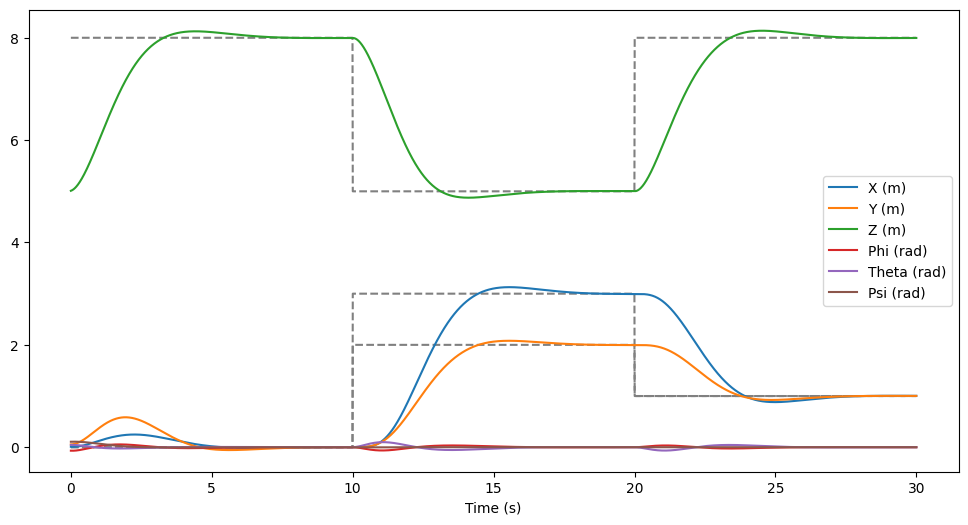

In [25]:
y0 = np.array([0, 0, 5] + 9*[0]) + 0.05*np.random.randn(12) # Initial state with small disturbances in all states
dt = 0.01 # seconds ... integration step for the simulation and animation
t_ref = 10 # seconds ... time to hold each reference
refs = np.array([[0, 0, 8], [3, 2, 5], [1, 1, 8]]) # References to follow in the simulation

# Simulation ... each reference is held for 10 seconds, taking 1000 samples in that interval
quadrotor_states = np.array([[] for _ in range(12)])
for ref in refs:
    states = solve_ivp_casadi(cl_quadrotor_fn, t_span=(0, t_ref), y0=y0 if quadrotor_states.size == 0 else quadrotor_states[:, -1],
                              N=int(t_ref/dt), u=ref)
    quadrotor_states = np.hstack([quadrotor_states, states.y])
t = np.linspace(0, 3*t_ref, quadrotor_states.shape[1])

# Plot references
for i in range(3):
    plt.plot(t, np.repeat(refs[:, i], int(t_ref/dt)), '--', color='gray')
# Plot states
for i, label in enumerate(['X (m)', 'Y (m)', 'Z (m)', 'Phi (rad)', 'Theta (rad)', 'Psi (rad)']):
    plt.plot(t, quadrotor_states[i], label=label)
plt.legend()
plt.xlabel('Time (s)')

### Oil well

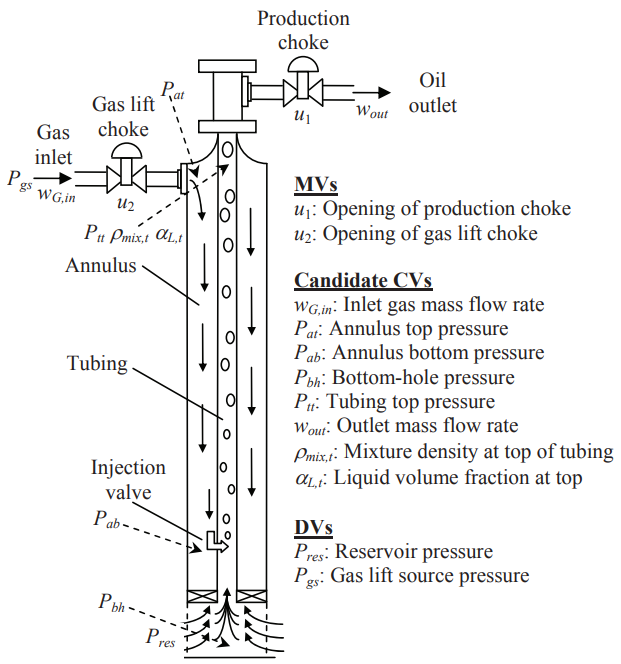

###### Image source: https://doi.org/10.3182/20120710-4-SG-2026.00110

States: $x = \begin{bmatrix} x_0 \\ x_1 \\ x_2 \end{bmatrix}$; Control actions: $u = \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$;
Algebraic states: $z = \begin{bmatrix} w_{G_in} \ P_{at} \ P_{ab} \ P_{bh} \ P_{tt} \ w_{out} \ \rho_{mix,t} \ \alpha_{L,t} \end{bmatrix}^T$

$x_0$ is the mass of gas in the annulus, $x_1$ is the mass of gas in the tubing, and $x_2$ is the mass of liquid in the tubing.

In [17]:
annulus_params = {
    'T_a': 348, # K
    'V_a': 64.34, # m^3
    'L_a': 2048, # m
    'K_gs': 9.98e-5,
    'K_inj': 1.4e-4,
}
gas_params = {
    'M_G': 16.7, # kg/mol
    'P_gs': 140, # bars
}
tubing_params = {
    'T_t': 350, # K
    'D_t': 0.124, # m
    'L_t': 1500, # m
    'V_t': 25.03, # m^3
    'epsilon': 2.8e-5, # m
    'K_pr': 2.9e-3,
    'P_out': 20, # bars
}
bottom_hole_params = {
    'S_bh': 0.0314, # m^2
    'L_bh': 75, # m
}
reservoir_params = {
    'P_res': 160, # bars
    'avg_w_res': 18, # kg/s
    'PI': 2.47e-6, # kg/s/Pa
    'GOR': 0,
}
oil_params = {
    'mu': 3.64e-3, # Pa.s
    'rho_L': 760, # kg/m^3
}

In [18]:
u_well = [0.5, 0.4] # Initial control actions ... [0.3, 0.4] stable, [0.5, 0.4] unstable
initial_guess = [
    3232, # mass of gas in the annulus ... if u0 = [0.3, 0.4], 3232 corresponds to the equilibrium
    269, # mass of gas in the tubing ... for u0 = [0.3, 0.4], 269 corresponds to the equilibrium
    10275, # mass of liquid in the tubing ... for u0 = [0.3, 0.4], 10275 corresponds to the equilibrium
]
simulation_time = 15*3600 # seconds

Text(0.5, 0, 'Time (h)')

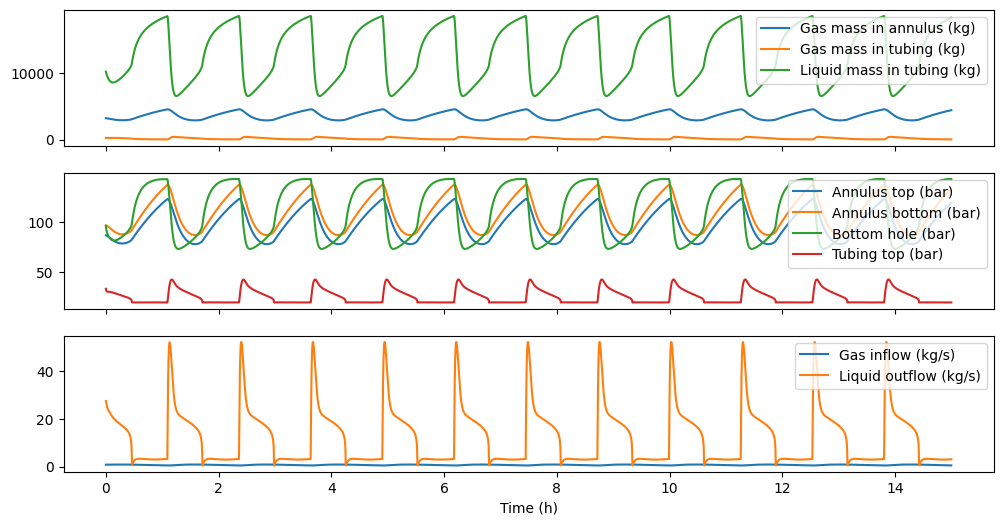

In [ ]:
oil_well_states = solve_dae_casadi(oil_well(**annulus_params, **gas_params, **tubing_params, **bottom_hole_params, **reservoir_params, **oil_params),
                                  t_span=(0, simulation_time), y0=initial_guess + [0]*8, yp0=np.zeros(11), u=u_well, N=simulation_time,
                                  opts={'reltol': 1e-6, 'abstol': 1e-6})

# First sample is the initial guess. We remove it.
t = oil_well_states.t[:-1]/3600 # hours
x_0, x_1, x_2, w_G_in, P_at, P_ab, P_bh, P_tt, w_out, *_ = [state[1:] for state in oil_well_states.y]

# Regroup the states
masses = [x_0, x_1, x_2]
pressures = [P_at, P_ab, P_bh, P_tt]
flows = [w_G_in, w_out]

# Plot the states
fig, axs = plt.subplots(3, 1, sharex=True)
for var, label in zip(masses,['Gas mass in annulus (kg)', 'Gas mass in tubing (kg)', 'Liquid mass in tubing (kg)']):
    axs[0].plot(t, var, label=label)
for var, label in zip(pressures,['Annulus top (bar)', 'Annulus bottom (bar)', 'Bottom hole (bar)', 'Tubing top (bar)']):
    axs[1].plot(t, var, label=label)
for var, label in zip(flows,['Gas inflow (kg/s)', 'Liquid outflow (kg/s)']):
    axs[2].plot(t, var, label=label)

for ax in axs:
    ax.legend(loc='upper right')
axs[-1].set_xlabel('Time (h)')

### pH Neutralization Process

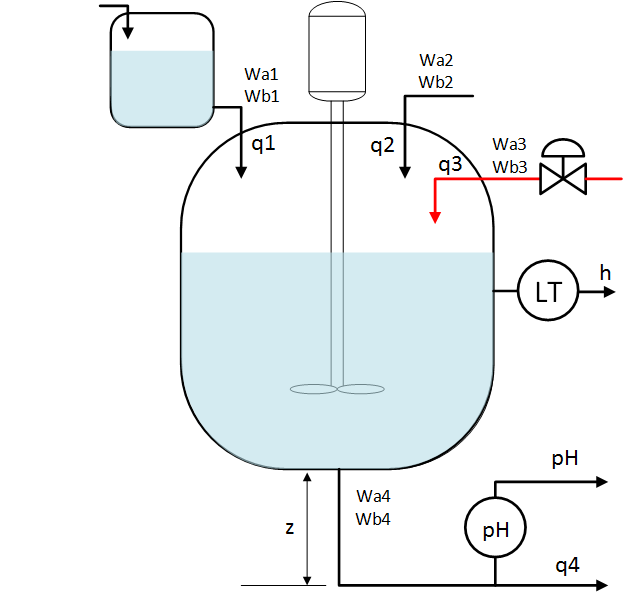

States: $x = \begin{bmatrix} W_{a4} \\ W_{b4} \\ h \\ pH \end{bmatrix}$; Control actions: $u = q_3$

In [24]:
reactor_params = {
    'A': 207, # cm^2
    'z': 11.5, # cm
}

buffer_tank_params = {
    'Cv4': 4.59,
    'n': 0.607,
}

# Reaction invariant concentrations
acid_inflow = { # Adds only H+ to the invariant concentrations.
    'Wa1': 3e-3, # mol/L
    'Wb1': 0, # mol/L
}
buffer_inflow = { # Reduces H+ and increases weak acid concentration
    'Wa2': -0.03, # mol/L
    'Wb2': 0.03, # mol/L
}
base_inflow = { # Reduces H+ and weak acid concentrations
    'Wa3': -3.05e-3, # mol/L
    'Wb3': -5e-5, # mol/L
}

dissociation_constants = {
    'pK1': 6.35, # 1st dissociation constant of H2CO3
    'pK2': 10.33, # 2nd dissociation constant of H2CO3
}

Text(0.5, 0, 'Time (s)')

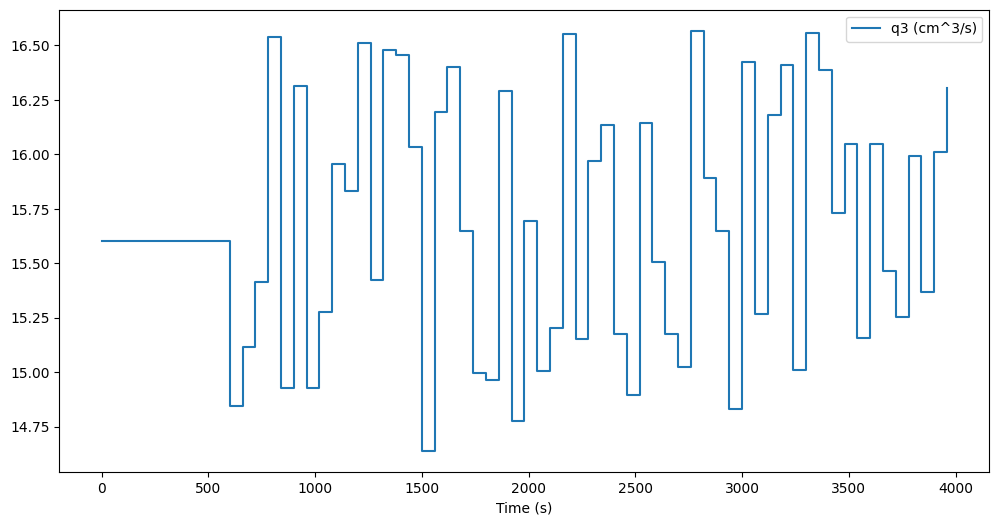

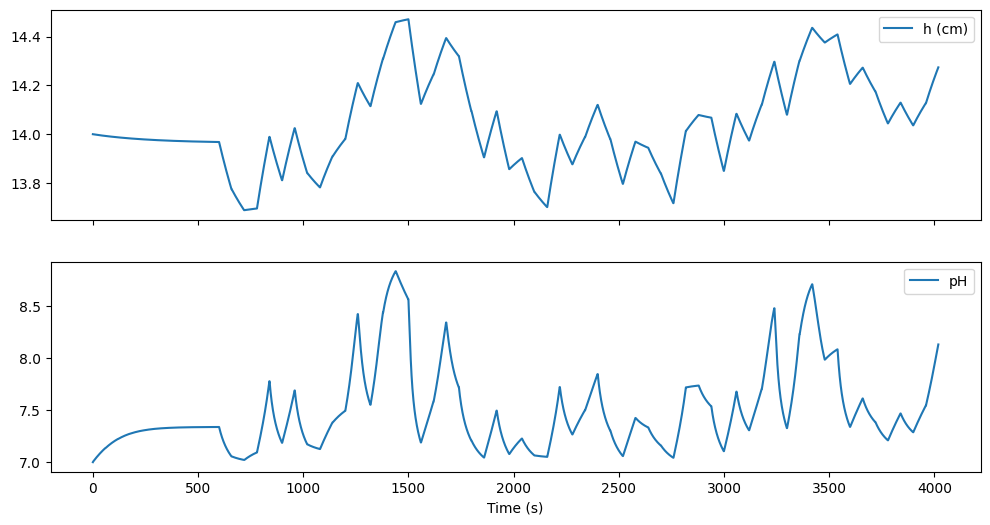

In [ ]:
duration = 4020 # seconds
step_duration = 60 # seconds
Ts = 1 # seconds

# Inlet flows
rangen = np.random.default_rng(seed=44)
k = np.arange(0, duration, step_duration)
q1 = 16.6 # cm^3/s
q2 = 0.55 # cm^3/s
q3 = np.full(len(k), 15.6) # cm^3/s
q3[10:] += rangen.uniform(-1, 1, len(k)-10) # cm^3/s

# Simulation of the neutralization process ... Every setpoint is held for 30 seconds
ph_states = np.array([[] for _ in range(4)])
ph_states_dot = np.array([[] for _ in range(4)])
for u_k in q3:
    # Solve the system keeping u_k for 30 seconds, taking a sample every second
    states = solve_dae_casadi(neutralization(**reactor_params, **buffer_tank_params, **acid_inflow, **buffer_inflow, **base_inflow, **dissociation_constants, q1=q1, d=q2),
                                t_span=(0, step_duration),
                                y0 = [-4.32e-4, 5.28e-4, 14, 7] if ph_states.size == 0 else ph_states[:, -1],
                                yp0 = np.zeros(4) if ph_states_dot.size == 0 else ph_states_dot[:, -1],
                                u=u_k, N=int(step_duration/Ts))
    # Append the states
    ph_states = np.hstack([ph_states, states.y])
    ph_states_dot = np.hstack([ph_states_dot, states.yp])

# Plot q3
plt.figure()
plt.step(k, q3, label='q3 (cm^3/s)', where='post')
plt.legend()
plt.xlabel('Time (s)')

# Plot measured states
fig, axs = plt.subplots(2, 1, sharex=True)
for i, label in enumerate(['h (cm)', 'pH']): 
    axs[i].plot(np.arange(0, duration, Ts), ph_states[i+2], label=label)
    axs[i].legend()
axs[-1].set_xlabel('Time (s)')